<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


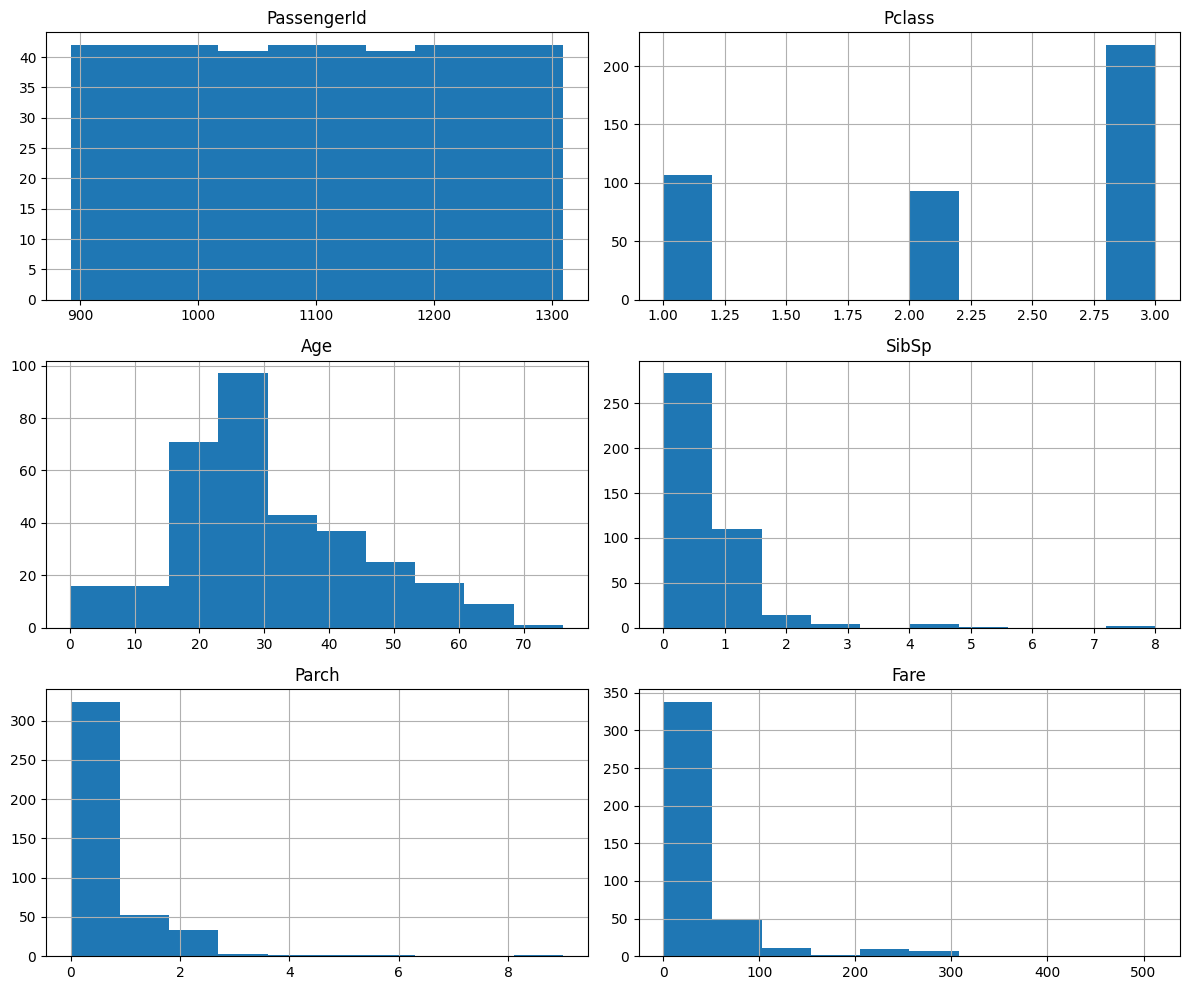

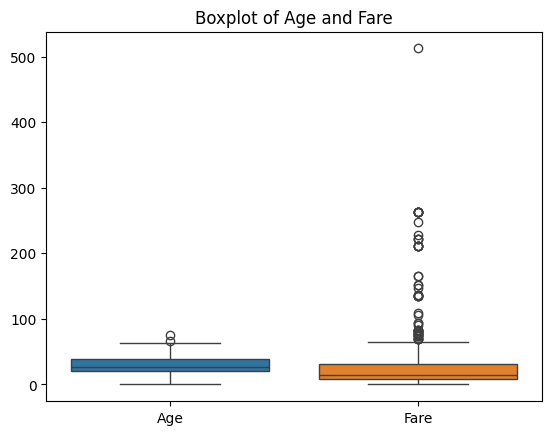

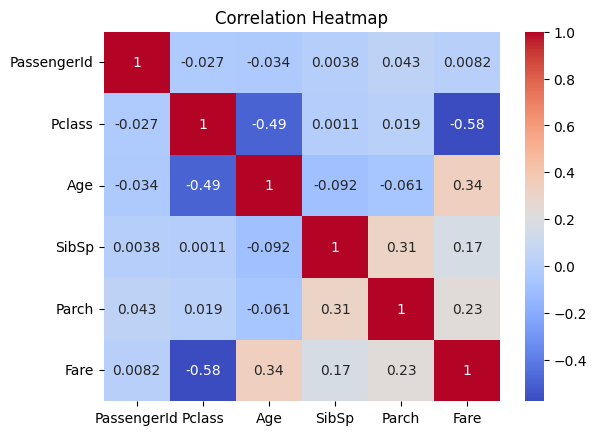

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Titanic_test.csv')
df.head()
df.info()
df.describe(include='all')

# Histograms
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

# Box plots
sns.boxplot(data=df[['Age', 'Fare']])
plt.title('Boxplot of Age and Fare')
plt.show()

# Correlation heatmap
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(columns=['Cabin', 'Name', 'Ticket', 'PassengerId'], inplace=True)

# Encode categorical variables
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

/tmp/ipython-input-1297048231.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-1297048231.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [18]:
# Simulate target variable (if not available)
df['Survived'] = np.random.randint(0, 2, size=len(df))  # Remove this if you have actual labels

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Train logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Accuracy: 0.5595238095238095
Precision: 0.5263157894736842
Recall: 0.5128205128205128
F1 Score: 0.5194805194805194
ROC AUC: 0.6045584045584046


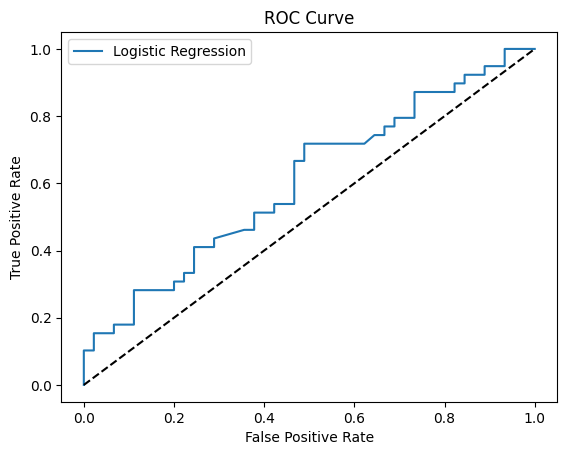

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [20]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coefficients)

      Feature  Coefficient
0      Pclass     0.179699
3       Parch     0.140983
5    Sex_male     0.117881
1         Age     0.011157
4        Fare    -0.002339
2       SibSp    -0.145095
6  Embarked_Q    -0.194063
7  Embarked_S    -0.480200


In [21]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load model
model = pickle.load(open('logistic_model.pkl', 'rb'))

# Title
st.title("Titanic Survival Predictor 🚢")

# Sidebar inputs
st.sidebar.header("Passenger Info")

def user_input():
    Pclass = st.sidebar.selectbox("Class", [1, 2, 3])
    Age = st.sidebar.slider("Age", 0, 80, 30)
    SibSp = st.sidebar.slider("Siblings/Spouses Aboard", 0, 8, 0)
    Parch = st.sidebar.slider("Parents/Children Aboard", 0, 6, 0)
    Fare = st.sidebar.slider("Fare", 0.0, 500.0, 50.0)
    Sex_male = st.sidebar.selectbox("Sex", ["Female", "Male"]) == "Male"
    Embarked_Q = st.sidebar.selectbox("Embarked at Q?", ["No", "Yes"]) == "Yes"
    Embarked_S = st.sidebar.selectbox("Embarked at S?", ["No", "Yes"]) == "Yes"

    data = {
        'Pclass': Pclass,
        'Age': Age,
        'SibSp': SibSp,
        'Parch': Parch,
        'Fare': Fare,
        'Sex_male': int(Sex_male),
        'Embarked_Q': int(Embarked_Q),
        'Embarked_S': int(Embarked_S)
    }
    return pd.DataFrame(data, index=[0])

input_df = user_input()

# Prediction
prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0][1]

# Output
st.subheader("Prediction")
st.write("Survived" if prediction == 1 else "Did Not Survive")

st.subheader("Survival Probability")
st.write(f"{probability:.2f}")

2025-09-16 14:13:03.839 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.840 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.841 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.842 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.843 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.844 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.845 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-16 14:13:03.847 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [22]:
import pickle

# Save the trained model
with open('logistic_model.pkl', 'wb') as f:
    pickle.dump(model, f)

1. What is the difference between precision and recall?
Precision: The ratio of true positive predictions to the total positive predictions made. It measures the accuracy of positive predictions.

Recall: The ratio of true positive predictions to the total actual positives. It measures the ability of the model to identify all relevant instances.

2. What is cross-validation, and why is it important in binary classification?
Cross-validation: A technique to evaluate the model's performance by splitting the dataset into multiple training and testing sets. The most common method is k-fold cross-validation.

Importance: It provides a more robust estimate of the model's performance by ensuring that the model is tested on different subsets of data, reducing the likelihood of overfitting and providing a better understanding of its generalization ability.